# BUILDING A NEUTRAL NETWORK FROM SCRATCH
AUTHOR: TEMITOPE FAROTIMI

DATE: 03/27/2026

This is my first "learning by doing" project for my program for mastering Machine Learning. 

The task is to build from scratch a simple neural network that takes as input the data for three variables (features) and train it to predict another variable.

Specifically, the objective is to create a SimpleNeuralNet class that:
   1. Builds two layers of neurons (3 and 2 neurons respectively).
   2. Performs a forward pass of training data.
   3. Calculates the loss (Mean Squared Error)
   4. Performs Gradient Descent to minimize the loss.
   5. Performs backpropagation to tune the weights at each neuron.
   6. Validates the network using a hold-out dataset and provides performance metrics.

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



In [28]:
np.set_printoptions(precision=3, suppress=True, linewidth=120)

In [ ]:
class SimpleNeuralNet():

    def __init__(self, dataset, target, test_split=0.2):
        assert dataset.shape[0] >= 30, "data train set must have >= 30 rows"

        self.target_name = target
        self.target = dataset[self.target_name]

        self.layers = {}

        self.outputs = {}
        self.activations = {}

        self.val_outputs = {}
        self.val_activations = {}


        self.features = dataset.drop(columns=[self.target_name])
        self.feature_names = self.features.columns
        self.no_features = len(self.features.columns)

        test_size = int(test_split * len(self.features))
        train_size = len(self.features) - test_size

        self.train_X = self.features.iloc[:-test_size]
        self.test_X = self.features.iloc[-test_size:]
        self.train_Y = self.target.iloc[:-test_size]
        self.test_Y = self.target.iloc[-test_size:]

        self.n_batches = None
        self.n_epochs = None
        self.n_learning_rate = None
        self.debug_backprop = False  # flip to True to watch delta travel

        print("Dataset: ", dataset.shape)
        print("Train Set: ", self.train_X.shape)
        print("Test Set: ", self.test_X.shape)

    def initialize_neurons(self, n_neurons: list):
        #initialize seed here so we get a new random from the same starting position...
        np.random.seed(42)
        
        self.n_neurons = n_neurons
        self.last_layer = len(n_neurons)

        for i, n in enumerate(n_neurons):
            fan_in = self.no_features if i == 0 else n_neurons[i - 1]
            self.layers[i + 1] = np.random.randn(fan_in, n) * np.sqrt(1 / fan_in)
            print(i + 1, self.layers[i + 1].shape)

        return self.layers

    def relu_activation(self, X) -> np.ndarray:
        return np.maximum(0, X)
    
    def forward_pass(self, outputs, activations):
        for j, layer in self.layers.items():
            prev = activations[j - 1]
            outputs[j] = prev @ layer
            if j == self.last_layer:
                activations[j] = outputs[j]
            else:
                activations[j] = self.relu_activation(outputs[j])

    def _process_batch(self):
        self.n_batches = int(len(self.train_X) / 10) + 1
        batch_mse = []

        for i in range(0, len(self.train_X), 10):
            batch = np.array(self.train_X.iloc[i:i + 10])
            self.activations[0] = batch
            
            self.forward_pass(self.outputs, self.activations)

            self.final = self.activations[self.last_layer]
            
            batch_train = np.array(self.train_Y[i:i + 10]).reshape(-1, 1)
            y_preds = np.array(self.final).reshape(-1, 1)

            mse = ((batch_train - y_preds) ** 2).mean()
            batch_mse.append(float(mse))

            self.back_prop(y_preds, batch_train)

        epoch_mse = float(np.mean(batch_mse))
            
        return epoch_mse

    def train_net(self, n_epochs = 200, lr=0.01):
        self.n_epochs = n_epochs
        self.n_learning_rate = lr

        self.loss_array = []
        self.val_loss_array = []

        for i in range(0, self.n_epochs):
            
            

            batch_loss = self._process_batch()

            val_loss = self.validate_net()

            if i % 10 == 0:
                print(f"Train/Validation Loss after {i} epochs: {batch_loss:.4f}, {val_loss:.4f}")

            self.loss_array.append(batch_loss)
            self.val_loss_array.append(val_loss)

        loss_plot = self.plot_loss(self.loss_array, self.val_loss_array)

        return loss_plot
    
    def plot_loss(self, loss_array, val_loss_array):
        plt.plot(loss_array, label='train')
        plt.plot(val_loss_array, label='validation')
        plt.xlabel('epoch')
        plt.ylabel('MSE')
        plt.legend()
        plt.show()

    def back_prop(self, output, batch_y):
        # find f'(output) of the loss function, sensitivy of loss function to output
        delta = 2 * (output - batch_y) / len(batch_y)

        if self.debug_backprop:
            print(f"\nstart: delta from loss has shape {delta.shape}")

        #Go back through the layers, the gradient at each layer is equal to the last gradient * the previous weights, 
        # where the neurons remained activated
        for j in reversed(list(self.layers.keys())):
            if self.debug_backprop:
                print(f"\n--- layer {j} ---")
                print(f"  delta arrived with shape {delta.shape}")

            if j != self.last_layer:
                delta = delta * (self.outputs[j] > 0)
                if self.debug_backprop:
                    print(f"  after ReLU mask:        {delta.shape}")

            #the grad_W is the amount of nudge to each weight, i.e the sensitivity of the output of the layer * by the activation in the previous layer, 
            # if activation = 0, neuron had no weight to input in the next layer, if > 0,
            # multiplying the nudged weight by the activation would have resulted in the correct weight in the next layer that would have reduced the loss. 
            
            grad_W = self.activations[j - 1].T @ delta
            if self.debug_backprop:
                print(f"  grad_W = activations[{j-1}].T @ delta  ->  {self.activations[j-1].T.shape} @ {delta.shape} = {grad_W.shape}")
                print(f"  (layers[{j}].shape is        {self.layers[j].shape}  -- must match grad_W)")

            #at the last layer, the new delta is the first delta (sensitivity of loss function to prediction) * the weight in the previous layer
            #which would have been the weight that contributed to the loss, so at each stage, 
            #delta is the sensitivity of the loss function to the value of each weight in the layer. 

            delta = delta @ self.layers[j].T
            if self.debug_backprop:
                print(f"  delta @ layers[{j}].T   ->  new delta {delta.shape}  (ready for layer {j-1})")

            #now, we nudge the weights in each layer by a portion of the nudge calculated at each weight during the delta * activation steps.  

            self.layers[j] -= self.n_learning_rate * grad_W

    def validate_net(self):
        #clear everything 
        self.val_activations = {}

        n_batches = int(len(self.test_X) / 10) + 1

        val_loss_array = []

        for i in range(0, len(self.test_X), 10):
            batch = np.array(self.test_X.iloc[i:i + 10])
            self.val_activations[0] = batch

            self.forward_pass(self.val_outputs, self.val_activations)

            final = self.val_activations[self.last_layer]
            batch_test = np.array(self.test_Y[i:i + 10]).reshape(-1, 1)
            y_preds = np.array(final).reshape(-1, 1)

            batch_loss = ((batch_test - y_preds) ** 2).mean()

            val_loss_array.append(batch_loss)

        val_loss = float(np.mean(val_loss_array))
        return val_loss



In [30]:
from sklearn.datasets import load_diabetes
import pandas as pd

# This dataset tracks disease progression based on age, bmi, bp, etc.
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)

# cell 5
raw_target = data.target
scaled_target = (raw_target - raw_target.mean()) / raw_target.std()
diabetes_df = pd.concat([df, pd.Series(scaled_target, name='target')], axis=1)


In [31]:
diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,-0.014719
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,-1.001659
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,-0.144580
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,0.699513
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,-0.222496


Dataset:  (442, 11)
Train Set:  (354, 10)
Test Set:  (88, 10)
1 (10, 10)
2 (10, 8)
3 (8, 6)
4 (6, 5)
5 (5, 2)
6 (2, 1)
0.7947381852769677
0.2756541625846907
1.0007710940686665
1.7085313712953003
0.8911029946264412
0.7025755091252017
0.49486995355220387
1.0069494627111526
0.9255946929327642
0.7661298769032416
0.8882019686150316
1.5655309664488022
0.4832566025019867
1.855130162203377
1.0257038723889575
1.3110378836370349
0.8810951513762356
0.9863931122131386
0.5429256011824881
0.6977022163272077
0.8119487197835822
1.342884952905501
0.7628233807521643
1.1217993582641461
1.1174365152229124
2.0264611859318173
1.287429141194612
0.8840522714535453
0.9222303092215052
1.4598696650089749
0.9545260229972083
0.2581401082824245
0.824494762789062
1.16062508678639
0.4976254434978909
0.9383414013538726
Train/Validation Loss after 0 epochs: 0.9771, 1.0911
0.7946628787533394
0.275627703742945
1.0005314061278932
1.7082129475414871
0.8909476851128989
0.7024885351171057
0.49480882883964983
1.00688351092215

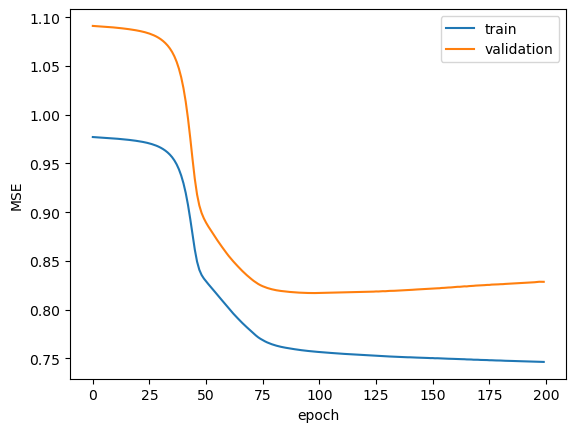

In [47]:
neural_net = SimpleNeuralNet(diabetes_df, "target")

layers = neural_net.initialize_neurons([10, 8, 6,5,2,1])
# layers = neural_net.initialize_neurons([10, 8, 6, 5, 2 , 1])


n_epochs = 200
lr = 0.02
trained_net = neural_net.train_net(n_epochs, lr)



In [35]:
print("train Y: mean %.3f  std %.3f" % (neural_net.train_Y.mean(), neural_net.train_Y.std()))
print("test  Y: mean %.3f  std %.3f" % (neural_net.test_Y.mean(),  neural_net.test_Y.std()))

train Y: mean -0.010  std 0.990
test  Y: mean 0.040  std 1.051
